In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("credit card.csv")
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [3]:
rows, cols = df.shape
print("Number of rows: ",rows)
print("Number of columns: ",cols)

Number of rows:  30000
Number of columns:  25


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

In [5]:
df.isna().sum()

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64

In [6]:
df.duplicated().sum()

0

In [7]:
df.rename(columns={"default.payment.next.month": "Payment"}, inplace=True)

In [8]:
df = df.drop("ID",axis=1)

In [9]:
df

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,Payment
0,20000.0,2,2,1,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,2,2,2,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,2,2,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,2,2,1,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,1,2,1,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000.0,1,3,1,39,0,0,0,0,0,...,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29996,150000.0,1,3,2,43,-1,-1,-1,-1,0,...,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29997,30000.0,1,2,2,37,4,3,2,-1,0,...,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1
29998,80000.0,1,3,1,41,1,-1,0,0,0,...,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1


In [10]:
cor = df.corr()["Payment"].to_frame()
cor

,Payment
LIMIT_BAL,-0.153520
SEX,-0.039961
EDUCATION,0.028006
MARRIAGE,-0.024339
AGE,0.013890
PAY_0,0.324794
PAY_2,0.263551
PAY_3,0.235253
PAY_4,0.216614
PAY_5,0.204149


In [11]:
cor = df.corr()["Payment"].to_frame().sort_values(by="Payment", ascending=False)
print(cor)


            Payment
Payment    1.000000
PAY_0      0.324794
PAY_2      0.263551
PAY_3      0.235253
PAY_4      0.216614
PAY_5      0.204149
PAY_6      0.186866
EDUCATION  0.028006
AGE        0.013890
BILL_AMT6 -0.005372
BILL_AMT5 -0.006760
BILL_AMT4 -0.010156
BILL_AMT3 -0.014076
BILL_AMT2 -0.014193
BILL_AMT1 -0.019644
MARRIAGE  -0.024339
SEX       -0.039961
PAY_AMT6  -0.053183
PAY_AMT5  -0.055124
PAY_AMT3  -0.056250
PAY_AMT4  -0.056827
PAY_AMT2  -0.058579
PAY_AMT1  -0.072929
LIMIT_BAL -0.153520


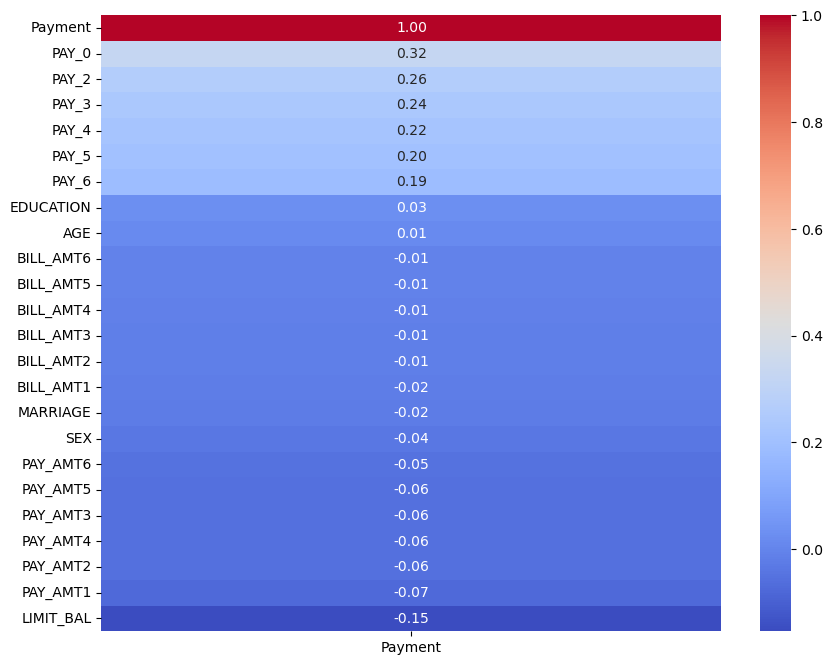

In [12]:
plt.figure(figsize=(10, 8))
sns.heatmap(cor, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()


## Dataset Separation

In [15]:
x = df.drop("Payment",axis=1)
y = df[["Payment"]]

In [24]:
x.shape

(30000, 23)

In [27]:
y.shape

(30000, 1)

In [28]:
y.head()

,Payment
0,1
1,1
2,0
3,0
4,0


# Feature Selection

## Wrapper Method

In [36]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings("ignore")

In [37]:
y.value_counts()

Payment
0          23364
1           6636
Name: count, dtype: int64

In [38]:
lr = LogisticRegression(class_weight="balanced", random_state=42)

In [42]:
rfe = RFE(lr, n_features_to_select=12)
rfe.fit(x,y)

RFE(estimator=LogisticRegression(class_weight='balanced', random_state=42),
    n_features_to_select=12)

In [43]:
rfe.score(x,y)

0.7211

In [44]:
rfe.support_

array([False,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True, False, False, False, False, False, False,  True,
        True, False, False, False, False])

In [45]:
# rfe.support_ → boolean array indicating which features were selected.
# x.columns[...] → picks the column names corresponding to True in rfe.support_.
col_name = x.columns[rfe.support_]
col_name

Index(['SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3',
       'PAY_4', 'PAY_5', 'PAY_6', 'PAY_AMT1', 'PAY_AMT2'],
      dtype='object')

In [46]:
rank = rfe.ranking_
rank

array([ 6,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, 10,  8,  9,  7, 12,  5,
        1,  1,  4,  2,  3, 11])

In [47]:
sel_fea = pd.DataFrame(rfe.support_, columns=['Selected Features'])
sel_fea

,Selected Features
0,False
1,True
2,True
3,True
4,True
5,True
6,True
7,True
8,True
9,True


In [48]:
new_col_name = pd.DataFrame(col_name, columns=['Corresponding Column Name'])
new_col_name

,Corresponding Column Name
0,SEX
1,EDUCATION
2,MARRIAGE
3,AGE
4,PAY_0
5,PAY_2
6,PAY_3
7,PAY_4
8,PAY_5
9,PAY_6


In [49]:
sel_fea2 = pd.DataFrame(rank, columns=['Features Ranking'])
sel_fea2

,Features Ranking
0,6
1,1
2,1
3,1
4,1
5,1
6,1
7,1
8,1
9,1


In [50]:
join = pd.concat([sel_fea, new_col_name,sel_fea2],axis=1)
join

,Selected Features,Corresponding Column Name,Features Ranking
0,False,SEX,6
1,True,EDUCATION,1
2,True,MARRIAGE,1
3,True,AGE,1
4,True,PAY_0,1
5,True,PAY_2,1
6,True,PAY_3,1
7,True,PAY_4,1
8,True,PAY_5,1
9,True,PAY_6,1


# nlargest(n, "column_name") → returns the top n rows sorted by that column. Works only for numeric columns.
top10 = new_col_name.nlargest(10, "new_col_name")
print(top10)

## Embedded Method

In [61]:
# Create a Logistic Regression model using L1 regularization (Lasso) with the 'liblinear' solver
embedded_lr = LogisticRegression(penalty= 'l1', solver='liblinear')

In [63]:
embedded_lr.fit(x,y)

LogisticRegression(penalty='l1', solver='liblinear')

In [65]:
coef = embedded_lr.coef_
coef

array([[-7.65765452e-07, -1.09638702e-01, -1.01879805e-01,
        -1.56057343e-01,  7.28277147e-03,  5.77157811e-01,
         8.27170934e-02,  7.21049195e-02,  2.38535412e-02,
         3.39587145e-02,  7.99145429e-03, -5.45927728e-06,
         2.29608847e-06,  1.39827617e-06, -1.90514841e-07,
         6.18109304e-07,  3.95870589e-07, -1.36069469e-05,
        -9.65036124e-06, -2.73802539e-06, -4.03160771e-06,
        -3.31274432e-06, -2.06623500e-06]])

In [71]:
for feature, coe in zip(x.columns, coef[0]):
    print(f"{feature} : {coe}")

LIMIT_BAL : -7.657654524398451e-07
SEX : -0.10963870197869949
EDUCATION : -0.10187980512767866
MARRIAGE : -0.1560573428584839
AGE : 0.007282771468276837
PAY_0 : 0.5771578106162507
PAY_2 : 0.08271709340137282
PAY_3 : 0.07210491948023455
PAY_4 : 0.02385354117849689
PAY_5 : 0.03395871448810278
PAY_6 : 0.007991454290573154
BILL_AMT1 : -5.459277279444499e-06
BILL_AMT2 : 2.2960884690330376e-06
BILL_AMT3 : 1.3982761714678155e-06
BILL_AMT4 : -1.9051484106150668e-07
BILL_AMT5 : 6.181093036298678e-07
BILL_AMT6 : 3.95870588969173e-07
PAY_AMT1 : -1.3606946858552032e-05
PAY_AMT2 : -9.650361241143773e-06
PAY_AMT3 : -2.738025386231866e-06
PAY_AMT4 : -4.0316077051787315e-06
PAY_AMT5 : -3.3127443223287226e-06
PAY_AMT6 : -2.066235000709544e-06


In [73]:
coef.nlargest(10, "Importance")

AttributeError: 'numpy.ndarray' object has no attribute 'nlargest'

## Filter Method

In [78]:
from sklearn.ensemble import ExtraTreesClassifier
etc = ExtraTreesClassifier()
etc.fit(x,y)

ExtraTreesClassifier()

In [80]:
etc.feature_importances_

array([0.06540254, 0.01129814, 0.03174399, 0.02289695, 0.06627026,
       0.10032941, 0.04528878, 0.03041584, 0.03170052, 0.03027747,
       0.03087529, 0.05023155, 0.04689172, 0.04530287, 0.04434873,
       0.04360911, 0.04425696, 0.04396097, 0.04234347, 0.04227035,
       0.04091091, 0.04303687, 0.04633727])

In [84]:
imp = pd.DataFrame(etc.feature_importances_, columns=['Importance'])
imp

,Importance
0,0.065403
1,0.011298
2,0.031744
3,0.022897
4,0.066270
5,0.100329
6,0.045289
7,0.030416
8,0.031701
9,0.030277


In [86]:
cols2 = pd.DataFrame(x.columns, columns = ['Columns'])
cols2

,Columns
0,LIMIT_BAL
1,SEX
2,EDUCATION
3,MARRIAGE
4,AGE
5,PAY_0
6,PAY_2
7,PAY_3
8,PAY_4
9,PAY_5


In [92]:
filjoin = pd.concat([imp,cols2],axis=1)
filjoin

,Importance,Columns
0,0.065403,LIMIT_BAL
1,0.011298,SEX
2,0.031744,EDUCATION
3,0.022897,MARRIAGE
4,0.066270,AGE
5,0.100329,PAY_0
6,0.045289,PAY_2
7,0.030416,PAY_3
8,0.031701,PAY_4
9,0.030277,PAY_5


# Implementation of PCA

In [98]:
from sklearn.decomposition import PCA
pca = PCA(n_components=3)

In [106]:
x_pca = pca.fit_transform(x)
x_pca

array([[-166488.19108561,  -75538.1536641 ,     472.95210554],
       [-114226.97681649,    9780.67125066,   -2734.44747685],
       [ -98432.36218047,  -33471.38733061,    2678.46979049],
       ...,
       [-140206.12804804,  -77857.4965395 ,  -26243.13338146],
       [ -41427.74077368,  -74908.30367175,  -17722.58797979],
       [ -70860.3112088 ,  -95514.14430929,   14117.46664521]])

In [108]:
pca_fea = pd.DataFrame(x_pca, columns=['Column1', 'Column2', 'Column3'])
pca_fea

,Column1,Column2,Column3
0,-166488.191086,-75538.153664,472.952106
1,-114226.976816,9780.671251,-2734.447477
2,-98432.362180,-33471.387331,2678.469790
3,-71230.675903,-95224.273104,10047.716972
4,-114834.618365,-68729.185233,-24604.948086
...,...,...,...
29995,200018.431424,-55465.636023,141623.472655
29996,-97718.568024,35089.032854,-4753.925193
29997,-140206.128048,-77857.496539,-26243.133381
29998,-41427.740774,-74908.303672,-17722.587980


In [110]:
pca_fea.shape

(30000, 3)

In [112]:
lr.fit(pca_fea, y)

LogisticRegression(class_weight='balanced', random_state=42)

In [114]:
lr.score(pca_fea, y)

0.5357333333333333

In [ ]:
lr.score(x,y)

In [116]:
lr.fit(x,y)

LogisticRegression(class_weight='balanced', random_state=42)

In [118]:
lr.score(x,y)

0.6654333333333333

In [120]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# scale first
x_scaled = StandardScaler().fit_transform(x)

# keep 95% variance
pca = PCA(n_components=0.95)
x_pca = pca.fit_transform(x_scaled)

print("Original shape:", x.shape)
print("Reduced shape:", x_pca.shape)


Original shape: (30000, 23)
Reduced shape: (30000, 15)
